# Graph-Based Fraud Detection using GCN

## 1. Data Loading & Initial Exploration

This section loads the raw transaction dataset and performs an initial inspection —
checking the shape, column types, and a preview of the data before any cleaning or modeling.

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/raw/Fraud_Data.csv')

print("Shape:", df.shape)
df.head()

Shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


### Observations
- Shape: 151,112 rows × 11 columns
- Columns:
  - `user_id` — unique identifier for each user
  - `signup_time`, `purchase_time` — timestamps (could derive a "time between signup and purchase" feature later)
  - `purchase_value` — transaction amount
  - `device_id` — shared across users who transact from the same device (key for graph construction)
  - `source`, `browser`, `sex`, `age` — user/session attributes
  - `ip_address` — shared across users on the same network (also key for graph construction)
  - `class` — target label (1 = fraud, 0 = legitimate)
- One row per transaction, no obvious missing columns from this preview.

## 2. Class Balance Check

Before modeling, we check how many fraud vs. legitimate transactions exist.
This matters because a heavily imbalanced dataset can cause a model to just predict
the majority class every time, without truly learning to detect fraud.

In [3]:
class_counts = df['class'].value_counts()
class_percent = df['class'].value_counts(normalize=True) * 100

print("Count:\n", class_counts)
print("\nPercentage:\n", class_percent)

Count:
 class
0    136961
1     14151
Name: count, dtype: int64

Percentage:
 class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


### Observations
- Class distribution: 136,961 legitimate (90.6%) vs. 14,151 fraud (9.4%)
- This is imbalanced but not extreme — with class weighting during training,
  the model should be able to learn real fraud patterns rather than defaulting
  to always predicting "legitimate."
- This imbalance will be handled later using `scale_pos_weight` in XGBoost.

## 3. Missing Values & Shared Identifiers Check

Checking for missing data, and checking how often `device_id` and `ip_address`
are shared across multiple transactions — this is what will form the edges
of our graph later.

In [4]:
print("Missing values per column:\n", df.isnull().sum())

print("\nUnique device_ids:", df['device_id'].nunique(), "out of", len(df), "rows")
print("Unique ip_addresses:", df['ip_address'].nunique(), "out of", len(df), "rows")

# How many devices/IPs are shared by more than one transaction?
shared_devices = (df['device_id'].value_counts() > 1).sum()
shared_ips = (df['ip_address'].value_counts() > 1).sum()

print("\nDevice IDs used by more than 1 transaction:", shared_devices)
print("IP addresses used by more than 1 transaction:", shared_ips)

Missing values per column:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Unique device_ids: 137956 out of 151112 rows
Unique ip_addresses: 143512 out of 151112 rows

Device IDs used by more than 1 transaction: 6175
IP addresses used by more than 1 transaction: 760


### Observations
- No missing values in any column — no imputation needed.
- 6,175 device IDs are used by more than one transaction (out of 137,956 unique devices).
- 760 IP addresses are used by more than one transaction (out of 143,512 unique IPs).
- This confirms there is real shared structure in the data — enough to build
  meaningful graph edges. Device sharing is more common than IP sharing here,
  so `device_id` will likely be the stronger signal for graph construction.

## 4. Does Sharing a Device/IP Correlate with Fraud?

This is the core hypothesis behind using a graph-based approach: if transactions
sharing a device or IP are more likely to be fraudulent, that's evidence a GNN
(which can "see" these shared connections) should outperform a model that treats
each transaction independently.

In [5]:
# Flag whether each transaction's device/IP is shared with another transaction
device_counts = df['device_id'].value_counts()
ip_counts = df['ip_address'].value_counts()

df['device_shared'] = df['device_id'].map(device_counts) > 1
df['ip_shared'] = df['ip_address'].map(ip_counts) > 1

print("Fraud rate when device IS shared:", df[df['device_shared']]['class'].mean())
print("Fraud rate when device NOT shared:", df[~df['device_shared']]['class'].mean())

print("\nFraud rate when IP IS shared:", df[df['ip_shared']]['class'].mean())
print("Fraud rate when IP NOT shared:", df[~df['ip_shared']]['class'].mean())

Fraud rate when device IS shared: 0.5245977962857586
Fraud rate when device NOT shared: 0.030429272808675

Fraud rate when IP IS shared: 0.9131578947368421
Fraud rate when IP NOT shared: 0.04565260031383098



### Observations
- Sharing a device is associated with a large jump in fraud rate: 52.5% vs. 3.0%.
- Sharing an IP address is associated with an even larger jump: 91.3% vs. 4.6%.
- This strongly validates the core hypothesis of this project — coordinated
  fraud clusters around shared devices/IPs, which a graph-based model can
  exploit directly, while a row-independent model (like plain XGBoost) can only
  approximate this through indirect features.
- This is a strong candidate for a headline result/slide in the final presentation.

## 5. Visualizing the Fraud Rate by Shared Device/IP

A simple bar chart to visualize the fraud rate difference — useful for the final presentation.

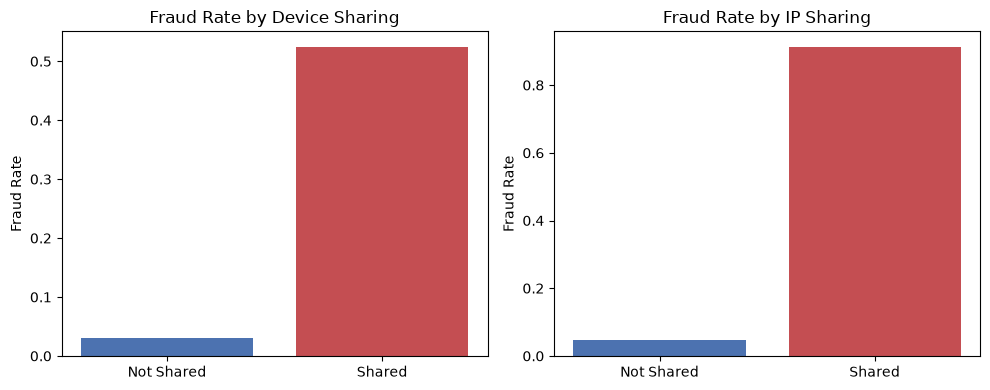

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Device sharing
device_rates = df.groupby('device_shared')['class'].mean()
axes[0].bar(['Not Shared', 'Shared'], device_rates.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Fraud Rate by Device Sharing')
axes[0].set_ylabel('Fraud Rate')

# IP sharing
ip_rates = df.groupby('ip_shared')['class'].mean()
axes[1].bar(['Not Shared', 'Shared'], ip_rates.values, color=['#4C72B0', '#C44E52'])
axes[1].set_title('Fraud Rate by IP Sharing')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()

import os
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/fraud_rate_by_sharing.png', dpi=150)
plt.show()

## 6. Feature Engineering

Before building the baseline model, we engineer a few features from the raw columns:
- `time_since_signup`: time between account signup and purchase (in seconds/hours) —
  fraudsters often transact very quickly after signup
- Encode categorical columns (`source`, `browser`, `sex`) so XGBoost can use them
- Drop identifier columns not usable directly as model features (`user_id`, `device_id`, `ip_address`)
  — note: `device_id`/`ip_address` themselves won't be direct model inputs, but the
  `device_shared`/`ip_shared` flags we already created will be used as features

In [7]:
# Feature: time between signup and purchase (in hours)
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
df['time_since_signup'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds() / 3600

# Encode categorical columns
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['source', 'browser', 'sex'], drop_first=True)

# Drop columns not usable as direct features
df_model = df_model.drop(columns=['user_id', 'device_id', 'ip_address', 'signup_time', 'purchase_time'])

print(df_model.shape)
df_model.head()

(151112, 13)


,purchase_value,age,class,device_shared,ip_shared,time_since_signup,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M
0,34,39,0,False,False,1251.856111,False,True,False,False,False,False,True
1,16,53,0,False,False,4.984444,False,False,False,False,False,False,False
2,15,53,1,True,True,0.000278,False,True,False,False,True,False,True
3,44,41,0,False,False,136.690278,False,True,False,False,False,True,True
4,39,45,0,False,False,1211.516944,False,False,False,False,False,True,True


## 7. Train/Test Split

We split the data before training, using stratification to preserve the same
fraud/legitimate ratio in both sets — important given the class imbalance.

In [8]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['class'])
y = df_model['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train shape: (120889, 12)
Test shape: (30223, 12)
Train fraud rate: 0.09364789186774644
Test fraud rate: 0.09363729609899746


## 8. XGBoost Baseline Model

Training an XGBoost classifier as our baseline — this treats each transaction
independently, with no awareness of the shared device/IP graph structure.
We use `scale_pos_weight` to address class imbalance so the model doesn't
default to always predicting "legitimate."

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Handle class imbalance: ratio of negative to positive class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

scale_pos_weight: 9.678296970232312
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     27393
           1       0.54      0.71      0.61      2830

    accuracy                           0.92     30223
   macro avg       0.76      0.82      0.78     30223
weighted avg       0.93      0.92      0.92     30223

PR-AUC: 0.7139961172091189


### Observations
- Baseline XGBoost achieves PR-AUC of 0.71, with 71% recall and 54% precision on fraud.
- This confirms the model is learning real fraud patterns, not just predicting
  the majority class (unlike some naive approaches on imbalanced data).
- This baseline treats every transaction independently — it can only use
  `device_shared`/`ip_shared` as flags, but cannot see *which* other specific
  transactions a device/IP connects to, or how large/suspicious that cluster is.
- The GCN (next section) should be able to exploit this richer relational
  structure directly, which is the hypothesis we'll test.

## 9. Building the Transaction Graph

Each transaction becomes a node. Two transactions are connected by an edge if they
share the same `device_id` or the same `ip_address` — this directly encodes the
"coordinated fraud" hypothesis validated in Section 4.

Node features: the same numeric/encoded features used in the XGBoost baseline
(purchase_value, age, time_since_signup, source/browser/sex encodings, etc.)
Node label: the `class` column (fraud or not)

In [10]:
import networkx as nx
from itertools import combinations

# Reset index so node IDs match row positions (0, 1, 2, ...)
df = df.reset_index(drop=True)

G = nx.Graph()
G.add_nodes_from(df.index)

# Group transactions by device_id, connect all transactions sharing a device
for device, group in df.groupby('device_id'):
    if len(group) > 1:
        for a, b in combinations(group.index, 2):
            G.add_edge(a, b, relation='device')

# Group transactions by ip_address, connect all transactions sharing an IP
for ip, group in df.groupby('ip_address'):
    if len(group) > 1:
        for a, b in combinations(group.index, 2):
            G.add_edge(a, b, relation='ip')

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Number of isolated nodes (no shared device/IP):", nx.number_of_isolates(G))

Number of nodes: 151112
Number of edges: 51708
Number of isolated nodes (no shared device/IP): 131781


### Observations
- 51,708 edges built from shared device_id/ip_address connections.
- 87% of nodes (131,781) are isolated — these transactions share no device/IP
  with any other transaction, consistent with the earlier finding that sharing
  is relatively rare (6,175 shared devices, 760 shared IPs out of 151k transactions).
- Expectation: the GCN's advantage over the XGBoost baseline should be most
  visible on the connected subset of nodes, since isolated nodes have no
  neighbor information for the GCN to exploit.

## 10. Converting to PyTorch Geometric Format

PyTorch Geometric needs three things:
- `x`: node feature matrix (same features as the XGBoost baseline)
- `edge_index`: the graph connections, in a specific 2-row tensor format
- `y`: node labels (fraud or not)

We also carry over the same train/test split indices used for XGBoost, so both
models are evaluated on the exact same test transactions — a fair comparison.

In [11]:
import torch
from torch_geometric.data import Data
import numpy as np

# Node features and labels (same as XGBoost, but as tensors)
feature_cols = X.columns.tolist()  # same features used in X earlier
x = torch.tensor(df_model[feature_cols].astype(float).values, dtype=torch.float)
y_tensor = torch.tensor(df_model['class'].values, dtype=torch.long)

# Convert edges to PyG format: a 2 x num_edges tensor
edges = list(G.edges())
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
# Make edges bidirectional (PyG treats edges as directed by default)
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

data = Data(x=x, edge_index=edge_index, y=y_tensor)

# Reuse the same train/test split (by index) as the XGBoost baseline
train_mask = torch.zeros(len(df_model), dtype=torch.bool)
test_mask = torch.zeros(len(df_model), dtype=torch.bool)
train_mask[X_train.index] = True
test_mask[X_test.index] = True

data.train_mask = train_mask
data.test_mask = test_mask

print(data)
print("Train nodes:", data.train_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())

Data(x=[151112, 12], edge_index=[2, 103416], y=[151112], train_mask=[151112], test_mask=[151112])
Train nodes: 120889
Test nodes: 30223


## 11. Defining the GCN Model

A Graph Convolutional Network works by having each node aggregate information from
its neighbors, layer by layer. This model has two GCN layers: the first lets each
node "absorb" info from its direct neighbors, the second lets it absorb info from
neighbors-of-neighbors — giving each node a richer, relationship-aware representation
before the final classification.

In [12]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):  
    def __init__(self, num_features, hidden_channels, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(num_features=data.x.shape[1], hidden_channels=32, num_classes=2)
print(model)

GCN(
  (conv1): GCNConv(12, 32)
  (conv2): GCNConv(32, 2)
)


## 12. Training the GCN

The training loop: for each epoch, the model makes predictions, we measure how
wrong it is (loss), and adjust the weights slightly to be less wrong. Repeated
over many epochs, the model gradually learns to use both node features and
graph structure to predict fraud.

We use class weighting in the loss function (same idea as `scale_pos_weight`
in XGBoost) so the model doesn't just learn to predict "not fraud" for everything.

In [13]:
# Class weights to handle imbalance (mirrors scale_pos_weight idea from XGBoost)
class_counts_train = torch.bincount(data.y[data.train_mask])
class_weights = 1.0 / class_counts_train.float()
class_weights = class_weights / class_weights.sum() * 2  # normalize

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()                          # clear old gradients
    out = model(data.x, data.edge_index)            # forward pass: make predictions
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=class_weights)  # measure error (only on train nodes)
    loss.backward()                                  # compute how to adjust weights
    optimizer.step()                                 # actually adjust the weights
    return loss.item()

losses = []
for epoch in range(1, 101):
    loss = train()
    losses.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 10, Loss: 61.6680
Epoch 20, Loss: 43.5419
Epoch 30, Loss: 25.4607
Epoch 40, Loss: 13.2667
Epoch 50, Loss: 5.8547
Epoch 60, Loss: 1.7296
Epoch 70, Loss: 1.2720
Epoch 80, Loss: 0.6821
Epoch 90, Loss: 1.2291
Epoch 100, Loss: 0.9610


## 13. Evaluating the GCN on the Test Set

We evaluate using the same metrics as the XGBoost baseline (precision, recall,
F1, PR-AUC) on the same test nodes, so the comparison is apples-to-apples.

In [14]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)[:, 1]  # probability of class "fraud"
    preds = out.argmax(dim=1)            # predicted class (0 or 1)

test_preds = preds[data.test_mask].numpy()
test_probs = probs[data.test_mask].numpy()
test_true = data.y[data.test_mask].numpy()

print(classification_report(test_true, test_preds))

precision, recall, _ = precision_recall_curve(test_true, test_probs)
gcn_pr_auc = auc(recall, precision)
print("GCN PR-AUC:", gcn_pr_auc)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     27393
           1       0.09      1.00      0.17      2830

    accuracy                           0.09     30223
   macro avg       0.05      0.50      0.09     30223
weighted avg       0.01      0.09      0.02     30223

GCN PR-AUC: 0.2112731380797372


c:\Users\Ritika Rastogi\gnn-fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ritika Rastogi\gnn-fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ritika Rastogi\gnn-fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

## 14. Fixing Feature Scaling & Retraining the GCN

The first GCN attempt underperformed the baseline, likely due to unscaled
features (e.g., `purchase_value` and `time_since_signup` have much larger
numeric ranges than the boolean flags). We standardize features and retrain.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_model[feature_cols].astype(float).values)

data.x = torch.tensor(x_scaled, dtype=torch.float)

# Rebuild model fresh (important: don't reuse old trained weights)
model = GCN(num_features=data.x.shape[1], hidden_channels=32, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

losses = []
for epoch in range(1, 101):
    loss = train()
    losses.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 10, Loss: 0.4540
Epoch 20, Loss: 0.4433
Epoch 30, Loss: 0.4254
Epoch 40, Loss: 0.4211
Epoch 50, Loss: 0.4177
Epoch 60, Loss: 0.4174
Epoch 70, Loss: 0.4160
Epoch 80, Loss: 0.4157
Epoch 90, Loss: 0.4149
Epoch 100, Loss: 0.4144


In [16]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)[:, 1]  # probability of class "fraud"
    preds = out.argmax(dim=1)            # predicted class (0 or 1)

test_preds = preds[data.test_mask].numpy()
test_probs = probs[data.test_mask].numpy()
test_true = data.y[data.test_mask].numpy()

print(classification_report(test_true, test_preds))

precision, recall, _ = precision_recall_curve(test_true, test_probs)
gcn_pr_auc = auc(recall, precision)
print("GCN PR-AUC:", gcn_pr_auc)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27393
           1       0.52      0.71      0.60      2830

    accuracy                           0.91     30223
   macro avg       0.74      0.82      0.78     30223
weighted avg       0.93      0.91      0.92     30223

GCN PR-AUC: 0.6566750273315205


## 15. Comparing Models on Connected vs. Isolated Nodes

The GCN's structural advantage should only matter for nodes that actually have
graph neighbors. We split the test set into connected vs. isolated nodes and
compare both models on each subset separately — this is a fairer test of
whether graph structure helps, rather than just comparing overall PR-AUC.

In [17]:
# Identify which test nodes are connected (non-isolated) vs isolated
degrees = dict(G.degree())
test_indices = X_test.index.values
is_connected = np.array([degrees.get(i, 0) > 0 for i in test_indices])

print("Connected test nodes:", is_connected.sum())
print("Isolated test nodes:", (~is_connected).sum())

# XGBoost predictions on connected vs isolated subsets
xgb_probs = y_pred_proba  # from Cell 20

for label, mask in [("Connected", is_connected), ("Isolated", ~is_connected)]:
    y_true_sub = y_test.values[mask]
    xgb_probs_sub = xgb_probs[mask]
    gcn_probs_sub = test_probs[mask]

    xgb_p, xgb_r, _ = precision_recall_curve(y_true_sub, xgb_probs_sub)
    gcn_p, gcn_r, _ = precision_recall_curve(y_true_sub, gcn_probs_sub)

    print(f"\n--- {label} nodes (n={mask.sum()}) ---")
    print("XGBoost PR-AUC:", auc(xgb_r, xgb_p))
    print("GCN PR-AUC:", auc(gcn_r, gcn_p))

Connected test nodes: 3891
Isolated test nodes: 26332

--- Connected nodes (n=3891) ---
XGBoost PR-AUC: 0.9288334043744132
GCN PR-AUC: 0.5223851912703078

--- Isolated nodes (n=26332) ---
XGBoost PR-AUC: 0.03073581017393994
GCN PR-AUC: 0.032604173363199186


## 16. Defining the GAT Model

In [18]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes, heads=4):
        super().__init__()
        self.conv1 = GATConv(num_features, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, num_classes, heads=1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GAT(num_features=data.x.shape[1], hidden_channels=8, num_classes=2, heads=4)
print(model)

GAT(
  (conv1): GATConv(12, 8, heads=4)
  (conv2): GATConv(32, 2, heads=1)
)


## 17. Training the GAT Model

Same training loop as the GCN — the only difference is the model architecture itself
(attention-based aggregation instead of simple averaging). Reusing the same class
weights and optimizer setup keeps the comparison fair.

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train_gat():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()
    return loss.item()

losses_gat = []
for epoch in range(1, 101):
    loss = train_gat()
    losses_gat.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 10, Loss: 0.4637
Epoch 20, Loss: 0.4572
Epoch 30, Loss: 0.4278
Epoch 40, Loss: 0.4269
Epoch 50, Loss: 0.4209
Epoch 60, Loss: 0.4194
Epoch 70, Loss: 0.4189
Epoch 80, Loss: 0.4172
Epoch 90, Loss: 0.4166
Epoch 100, Loss: 0.4156


## 18. Evaluating the GAT Model

Same evaluation as the GCN — precision, recall, F1, and PR-AUC on the test set —
so we can do a direct, fair comparison.

In [20]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs_gat = F.softmax(out, dim=1)[:, 1]
    preds_gat = out.argmax(dim=1)

test_preds_gat = preds_gat[data.test_mask].numpy()
test_probs_gat = probs_gat[data.test_mask].numpy()

print(classification_report(test_true, test_preds_gat))

precision, recall, _ = precision_recall_curve(test_true, test_probs_gat)
gat_pr_auc = auc(recall, precision)
print("GAT PR-AUC:", gat_pr_auc)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27393
           1       0.52      0.71      0.60      2830

    accuracy                           0.91     30223
   macro avg       0.74      0.82      0.78     30223
weighted avg       0.93      0.91      0.92     30223

GAT PR-AUC: 0.6598480679604254


In [21]:
for label, mask in [("Connected", is_connected), ("Isolated", ~is_connected)]:
    y_true_sub = y_test.values[mask]
    xgb_probs_sub = xgb_probs[mask]
    gcn_probs_sub = test_probs[mask]
    gat_probs_sub = test_probs_gat[mask]

    xgb_p, xgb_r, _ = precision_recall_curve(y_true_sub, xgb_probs_sub)
    gcn_p, gcn_r, _ = precision_recall_curve(y_true_sub, gcn_probs_sub)
    gat_p, gat_r, _ = precision_recall_curve(y_true_sub, gat_probs_sub)

    print(f"\n--- {label} nodes (n={mask.sum()}) ---")
    print("XGBoost PR-AUC:", auc(xgb_r, xgb_p))
    print("GCN PR-AUC:", auc(gcn_r, gcn_p))
    print("GAT PR-AUC:", auc(gat_r, gat_p))


--- Connected nodes (n=3891) ---
XGBoost PR-AUC: 0.9288334043744132
GCN PR-AUC: 0.5223851912703078
GAT PR-AUC: 0.5216787950571102

--- Isolated nodes (n=26332) ---
XGBoost PR-AUC: 0.03073581017393994
GCN PR-AUC: 0.032604173363199186
GAT PR-AUC: 0.031775977997562016


## 19. Model Explainability with SHAP

While the feature importance chart shows which features matter *overall*,
SHAP explains *individual* predictions — which is critical for real-world
fraud systems, where an analyst needs to justify why a specific transaction
was flagged. This uses SHapley Additive exPlanations, a game-theory-based
method for attributing a prediction to each input feature.

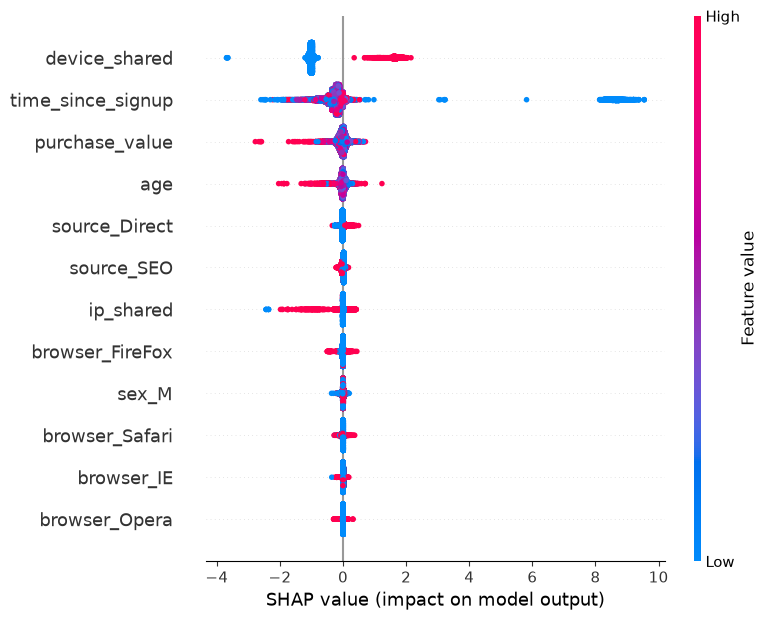

In [22]:
import shap

explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_test)

# Global summary: which features matter most, and in which direction
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Actual class: 1
Predicted probability of fraud: 0.68408805


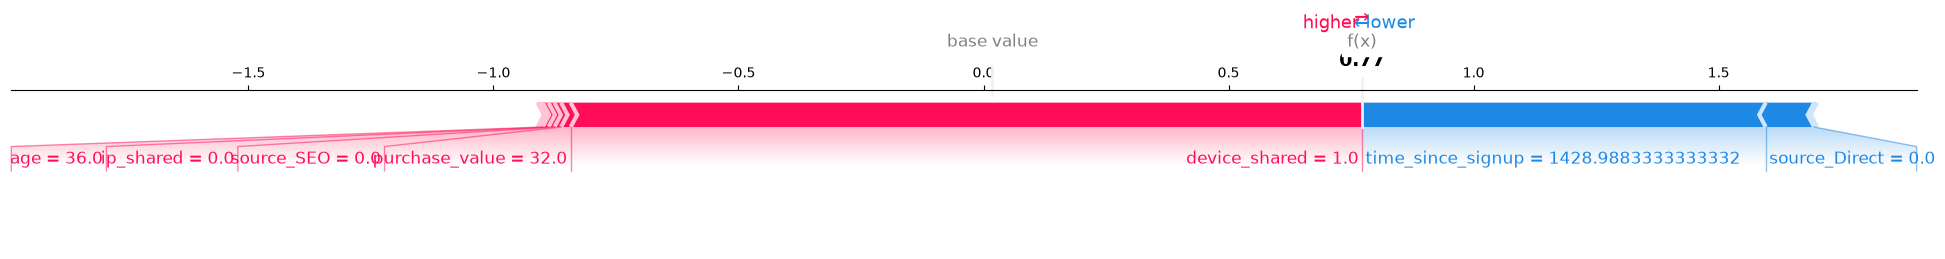

In [23]:
# Pick one transaction the model correctly flagged as fraud
fraud_idx = X_test[(y_test == 1) & (y_pred == 1)].index[0]
row_position = X_test.index.get_loc(fraud_idx)

print("Actual class:", y_test.loc[fraud_idx])
print("Predicted probability of fraud:", y_pred_proba[row_position])

shap.force_plot(
    explainer.expected_value,
    shap_values[row_position],
    X_test.loc[fraud_idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_single_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- For this correctly-flagged fraud transaction, `device_shared=1.0` was by far
  the dominant driver pushing the prediction toward fraud — visually confirming
  the hypothesis validated in Section 4 at the level of an individual prediction,
  not just in aggregate.
- Minor countervailing factors (a long 59-day gap since signup, non-direct
  traffic source) pulled the prediction down slightly, but were not enough to
  outweigh the device-sharing signal.
- This demonstrates the model's decision-making is interpretable and aligns
  with domain intuition — an important property for real-world fraud systems,
  where analysts need to justify flagged transactions.